# End to End Showcase: Book Portrait AI

Runs the exact same pipeline as [`book_portrait_ai/app.py`](../book_portrait_ai/app.py) in three stages, calling the same underlying functions the Gradio app calls, just cell by cell instead of through the UI. Useful for testing or showcasing the whole flow without spinning up the app.

1. **Semantic chunking** (Part 1): `book_portrait_ai.semantic_chunking.pipeline.process_document`
2. **Character & atmosphere extraction** (Part 2): `book_portrait_ai.feature_extraction_bridge.extract_characters_and_atmosphere`
3. **Image prompt generation** (Part 3): `book_portrait_ai.image_prompt_bridge.generate_image_prompts`

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from book_portrait_ai.character_extraction import count_character_names, load_nlp, resolve_title_references
from book_portrait_ai.feature_extraction_bridge import extract_characters_and_atmosphere
from book_portrait_ai.image_prompt_bridge import generate_image_prompts
from book_portrait_ai.semantic_chunking.config import DEFAULT_ENCODING, DEFAULT_MODEL
from book_portrait_ai.semantic_chunking.pipeline import process_document

DATA_DIR = Path.cwd().parent / 'data'
BOOK_PATH = DATA_DIR / 'dracula.txt'

# Same defaults as the sliders in book_portrait_ai/app.py
MIN_TOKENS = 200
MAX_TOKENS = 1000
BREAKPOINT_PERCENTILE = 20
OVERLAP_UNITS = 1
NAME_THRESHOLD = 5
MAX_CHARACTERS = 5

# How many of each character's matched chunks (ranked by mention density)
# get fed to the LLM when building their profile. Not exposed in the app,
# notebook only.
MAX_CHUNKS_PER_CHARACTER = 5

c:\Users\johan\OneDrive\Desktop\Meu PC\Estudo\Regensburg\2 Semester\Gen AI\GenAI_Project_From_Scratch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Semantic chunking (Part 1)

Uploads, cleans, and semantically chunks the book. Same as clicking "Chunk text semantically" in the app.

In [2]:
status, preview_rows, cleaned_path, jsonl_path, cleaned_text, chunks = process_document(
    uploaded_file=str(BOOK_PATH),
    min_tokens=MIN_TOKENS,
    max_tokens=MAX_TOKENS,
    breakpoint_percentile=BREAKPOINT_PERCENTILE,
    overlap_units=OVERLAP_UNITS,
    encoding_name=DEFAULT_ENCODING,
    model_name=DEFAULT_MODEL,
    strip_gutenberg=True,
)

print(status)
print(f'\nCleaned text exported to: {cleaned_path}')
print(f'Chunks exported to: {jsonl_path}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5032.13it/s]


### Semantic chunking complete
- **File:** `dracula.txt`
- **Characters:** 845,675
- **Tokens:** 213,523
- **Atomic units:** 2,810
- **Chunks:** 327
- **Semantic threshold:** 0.192
- **Chunk size:** 200–1000 tokens
- **Overlap:** 1 unit(s)
- **Model:** `sentence-transformers/all-MiniLM-L6-v2`

Cleaned text exported to: C:\Users\johan\AppData\Local\Temp\semantic_chunking_cwa808z8\dracula_cleaned.txt
Chunks exported to: C:\Users\johan\AppData\Local\Temp\semantic_chunking_cwa808z8\dracula_chunks.jsonl


In [3]:
# Preview of the first few chunks, same columns as the app's preview table
preview_rows[:5]

[[0,
  443,
  'semantic_shift',
  'DRACULA  _by_  Bram Stoker  [Illustration: colophon]  NEW YORK  GROSSET & DUNLAP  _Publishers_  Copyright, 1897, in the United States of America, according to Act of Congress, by Bram Stoker  [_All rights reserved._]  PRINTED IN THE UNITED STATES AT THE COUNTRY LIFE PRESS, GARDEN CITY, N.Y.  TO  MY DEAR FRIEND  HOMMY-BEG  Contents  CHAPTER I. Jonathan Harker’s Journal CHAPTER II. Jonathan Harker’s …'],
 [1,
  766,
  'semantic_shift',
  'How these papers have been placed in sequence will be made manifest in the reading of them. All needless matters have been eliminated, so that a history almost at variance with the possibilities of later-day belief may stand forth as simple fact. There is throughout no statement of past things wherein memory may err, for all the records chosen are exactly contemporary, given from the standpoints a …'],
 [2,
  654,
  'semantic_shift',
  'I read that every known superstition in the world is gathered into the horseshoe of

## Character name detection: before and after title resolution

spaCy's NER only tags explicit names, so a character who is mostly referred to by title (e.g. Dracula being called "the Count" throughout most of the book) ends up undercounted. `resolve_title_references` looks for a title ever glued directly to a name somewhere in the text (e.g. "Count Dracula"), and if that anchor is unique to one character, attributes every bare use of that title (e.g. "the Count") to them.

This cell runs name detection twice so you can compare the counts directly.

In [4]:
nlp = load_nlp()
chunk_texts = [chunk['text'] for chunk in chunks]

name_counts_before = count_character_names(cleaned_text, nlp, threshold=NAME_THRESHOLD)
name_counts_after = resolve_title_references(chunk_texts, name_counts_before)

print('Top characters before title resolution:')
for name, count in list(name_counts_before.items())[:10]:
    print(f'  {name}: {count}')

print('\nTop characters after title resolution:')
for name, count in list(name_counts_after.items())[:10]:
    print(f'  {name}: {count}')

Top characters before title resolution:
  van helsing: 299
  lucy: 291
  jonathan: 206
  arthur: 143
  harker: 111
  seward: 101
  quincey: 84
  john: 73
  mina: 53
  morris: 49

Top characters after title resolution:
  van helsing: 460
  lucy: 291
  dracula: 220
  jonathan: 206
  arthur: 143
  harker: 111
  seward: 101
  quincey: 84
  john: 74
  mina: 53


## 2. Character & atmosphere extraction (Part 2)

Reuses the semantic chunks from Part 1. Same as clicking "Extract characters & atmosphere" in the app.

In [5]:
status, name_rows, character_profiles, book_atmosphere = extract_characters_and_atmosphere(
    cleaned_text=cleaned_text,
    chunks=chunks,
    name_threshold=NAME_THRESHOLD,
    max_characters=MAX_CHARACTERS,
    max_chunks_per_character=MAX_CHUNKS_PER_CHARACTER,
)

print(status)
print('\nDetected characters:')
for name, count, aliases in name_rows:
    alias_suffix = f' (also known as: {aliases})' if aliases else ''
    print(f'  {name}: {count}{alias_suffix}')

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 2881.52it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corr

Successfully processed: van helsing


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Successfully processed: lucy


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Successfully processed: dracula
### Character & atmosphere extraction complete
- **Detected characters:** 37
- **Profiled characters:** 3 (limited to max. 3)
- **Minimum mentions:** 5

Detected characters:
  van helsing: 460 (also known as: the Professor)
  lucy: 291
  dracula: 220 (also known as: the Count)


In [6]:
character_profiles

{'van helsing': {'physical_appearance': 'beautiful, pale, and gaunt',
  'personality_traits': ['brave', 'strong-willed', 'caring'],
  'signature_pose_or_expression': 'voluptuous smile, wanton gaze',
  'vibe_and_mood': 'sadistic, cruel, and dangerous',
  'creature_type': 'human',
  'attire': None,
  'mentions': 460,
  'aliases': ['the Professor']},
 'lucy': {'physical_appearance': 'Snow-white, half-reclining figure',
  'personality_traits': ['cruel', 'voluptuous', 'unholy'],
  'signature_pose_or_expression': 'Languorous, voluptuous grace, wanton smile',
  'vibe_and_mood': 'Despair, hatred, disgust',
  'creature_type': 'Un-Dead',
  'attire': None,
  'mentions': 291,
  'aliases': []},
 'dracula': {'physical_appearance': 'tall, clean-shaven save for a long white moustache, dressed entirely in black',
  'personality_traits': ['demonic', 'calculating', 'powerful'],
  'signature_pose_or_expression': 'with a grim sort of smile, which showed more than he had yet done his protuberant teeth, sitt

In [7]:
book_atmosphere

{'overall_mood_keywords': ['mysterious', 'frightening', 'ominous'],
 'visual_palette_and_lighting': 'dim, eerie, shadowy',
 'narrative_tone_progression': 'The narrative progresses from a sense of foreboding and unease in the beginning, intensifying to a tense anticipation of danger and conflict throughout the middle, culminating in a final resolution marked by relief and triumph.'}

In [8]:
no_atmosphere = {
    'overall_mood_keywords': [],
    'visual_palette_and_lighting': '',
    'narrative_tone_progression': '',
}

## 3. Image prompt generation (Part 3)

One image prompt per profiled character, using their profile and the book's atmosphere. Same as clicking "Generate image prompts" in the app.

In [10]:
status, image_prompts = generate_image_prompts(character_profiles, no_atmosphere)

print(status)

llm_prompt: 
Based on the following information, create a detailed image generation prompt.

BOOK AESTHETIC (shared backdrop/atmosphere across all characters, not the main focus):
Mood: 
 Settings: 

Image Artistic style: digital illustration, storybook art style, painterly texture, expressive brushwork, cohesive composition

CHARACTER INFORMATION (this character should be the main visual focus):
Character Name: Van Helsing
 Personality: brave, strong-willed, caring
 Description: beautiful, pale, and gaunt
 Signature Pose/Expression: voluptuous smile, wanton gaze
 Character Mood: sadistic, cruel, and dangerous
 Creature/Species: human
 
Generating Image prompt.....


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 3665.52it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'do_sample', 'top_p', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Image Prompt:
Van Helsing stands tall against a moonlit night sky, his pale skin contrasting sharply with the darkness around him. His eyes gleam with a sadistic gleam as he looks at the viewer with a lustful gaze. He holds a small dagger in one hand, ready to strike, while his other arm extends out, seemingly reaching towards someone unseen. The scene is bathed in a soft, ethereal light, giving Van Helsing an almost painterly quality to him. His posture conveys both strength and vulnerability simultaneously, embodying the character's dual nature of bravery and cruelty.
llm_prompt: 
Based on the following information, create a detailed image generation prompt.

BOOK AESTHETIC (shared backdrop/atmosphere across all characters, not the main focus):
Mood: 
 Settings: 

Image Artistic style: digital illustration, storybook art style, painterly texture, expressive brushwork, cohesive composition

CHARACTER INFORMATION (this character should be the main visual focus):
Character Nam

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Image Prompt:
Lucy, snow-white and half-reclined, looms over her victims with languorous grace and a sultry, wanton smile. Her pallid skin casts eerie shadows as she glistens in the dim light of the candlelit room, her expression a twisted parody of despair, hatred, and disgust. The air is thick with malevolence, and the oppressive atmosphere is palpable. Her ethereal form seems almost otherworldly, yet there is a raw, visceral power emanating from her.
llm_prompt: 
Based on the following information, create a detailed image generation prompt.

BOOK AESTHETIC (shared backdrop/atmosphere across all characters, not the main focus):
Mood: 
 Settings: 

Image Artistic style: digital illustration, storybook art style, painterly texture, expressive brushwork, cohesive composition

CHARACTER INFORMATION (this character should be the main visual focus):
Character Name: Dracula
 Personality: demonic, calculating, powerful
 Description: tall, clean-shaven save for a long white moustach

In [11]:
for character_name, prompt in image_prompts.items():
    print(f'--- {character_name} ---')
    print(prompt)
    print()

--- Van Helsing ---
Van Helsing stands tall against a moonlit night sky, his pale skin contrasting sharply with the darkness around him. His eyes gleam with a sadistic gleam as he looks at the viewer with a lustful gaze. He holds a small dagger in one hand, ready to strike, while his other arm extends out, seemingly reaching towards someone unseen. The scene is bathed in a soft, ethereal light, giving Van Helsing an almost painterly quality to him. His posture conveys both strength and vulnerability simultaneously, embodying the character's dual nature of bravery and cruelty.

--- Lucy ---
Lucy, snow-white and half-reclined, looms over her victims with languorous grace and a sultry, wanton smile. Her pallid skin casts eerie shadows as she glistens in the dim light of the candlelit room, her expression a twisted parody of despair, hatred, and disgust. The air is thick with malevolence, and the oppressive atmosphere is palpable. Her ethereal form seems almost otherworldly, yet there is a

## Freeing GPU memory before image generation

Parts 2 and 3 both use the same small local model (Qwen2.5-1.5B-Instruct), and it stays cached in GPU memory across calls so it does not get reloaded every time. That is fine on its own, but Part 4 loads a Stable Diffusion pipeline, which needs GPU memory too. On a 6GB laptop GPU (the reason Qwen2.5-1.5B was chosen over a 7B model in the first place), keeping the text model and the image model resident at the same time can be tight or fail outright.

Running this cell releases both text models from GPU memory before Part 4 loads Stable Diffusion. It is safe to run even if a model was never loaded, or if you are on a CPU only setup, it just prints what it did.

If you go back and re-run Part 2 or Part 3 afterwards, that is fine too, they simply reload the model.

In [12]:
from book_portrait_ai import gpu_utils
from book_portrait_ai.feature_extraction_bridge import unload_text_extraction_model
from book_portrait_ai.image_prompt_bridge import unload_image_prompt_model

print('Before:', gpu_utils.describe_gpu_memory())

unload_text_extraction_model()
unload_image_prompt_model()

print('After: ', gpu_utils.describe_gpu_memory())

Before: GPU memory: 6.28 GB allocated, 9.51 GB reserved.
Unloaded Qwen/Qwen2.5-1.5B-Instruct (character extraction).
Unloaded Qwen/Qwen2.5-1.5B-Instruct (image prompt generation).
After:  GPU memory: 0.10 GB allocated, 0.11 GB reserved.


## 4. Image generation (Part 4)

Renders one portrait per profiled character locally, using Stable Diffusion 1.5, based on the prompts from Part 3. Same as clicking "Generate images" in the app. This step downloads the Stable Diffusion weights the first time it runs (a few GB), and can take a while to generate all portraits on a laptop GPU.

In [13]:
from IPython.display import display

from book_portrait_ai.image_generation_bridge import generate_character_images

In [14]:
image_prompts['Lucy']

'Lucy, snow-white and half-reclined, looms over her victims with languorous grace and a sultry, wanton smile. Her pallid skin casts eerie shadows as she glistens in the dim light of the candlelit room, her expression a twisted parody of despair, hatred, and disgust. The air is thick with malevolence, and the oppressive atmosphere is palpable. Her ethereal form seems almost otherworldly, yet there is a raw, visceral power emanating from her.'

In [15]:
status, character_images = generate_character_images(image_prompts)

print(status)

[transformers] `CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
[transformers] `SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.
c:\Users\johan\OneDrive\Desktop\Meu PC\Estudo\Regensburg\2 Semester\Gen AI\GenAI_Project_From_Scratch\.venv\Lib\site-packages\diffusers\utils\deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
100%|██████████| 25/25 [00:05<00:00,  4.59it/s]


Generated image: Van Helsing


100%|██████████| 25/25 [00:04<00:00,  5.08it/s]


Generated image: Lucy


100%|██████████| 25/25 [00:04<00:00,  5.05it/s]


Generated image: Dracula
### Image generation complete
- **Generated images:** 3 / 3


--- Van Helsing ---


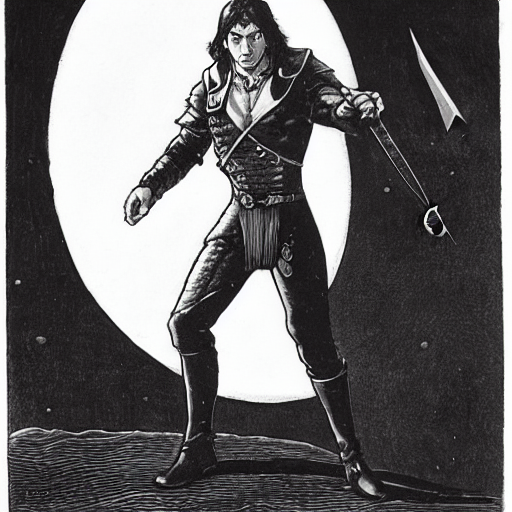

--- Lucy ---


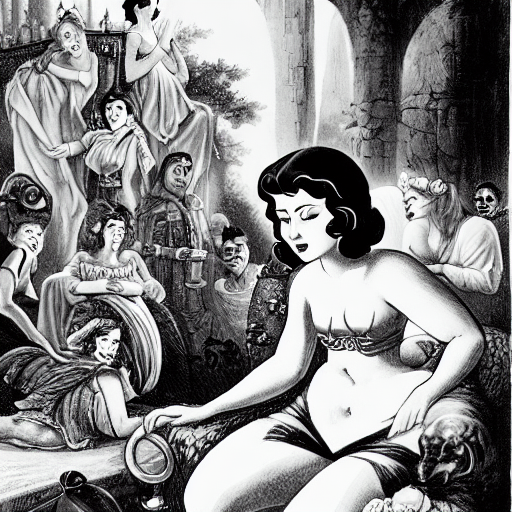

--- Dracula ---


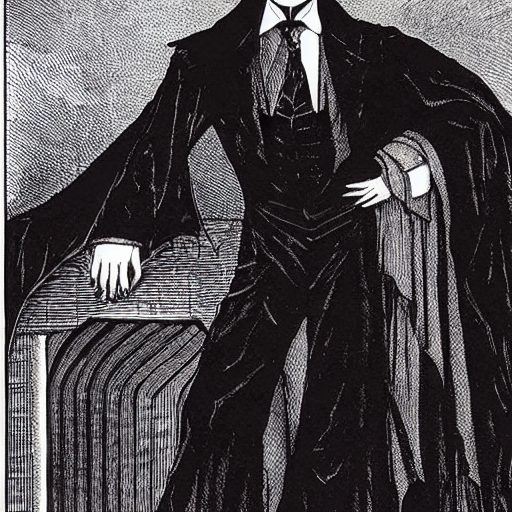

In [16]:
for image, character_name in character_images:
    print(f'--- {character_name} ---')
    display(image)